<a href="https://colab.research.google.com/github/SaraRapalino/Telecom-X-parte2/blob/main/Telecom%20parte%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🛠️Preparación de los Datos**

In [8]:
import pandas as pd

url = "https://raw.githubusercontent.com/SaraRapalino/Telecom-X-parte2/main/TelecomX_tratado.csv"

df = pd.read_csv(url)
df.head()

,customerID,Churn,Genero,customer.SeniorCitizen,Pareja,Dependientes,customer.tenure,ServicioTelefono,LineasMultiples,ServicioInternet,...,ProteccionDispositivo,SoporteTecnico,StreamingTV,StreamingPeliculas,Contrato,FacturacionSinPapel,MetodoPago,account.Charges.Monthly,TotalFacturado,Cuentas_Diarias
0,0002-ORFBO,0,0,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,1,1,Mailed check,65.6,593.30,2.197407
1,0003-MKNFE,0,1,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,0,0,Mailed check,59.9,542.40,2.008889
2,0004-TLHLJ,1,1,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,0,1,Electronic check,73.9,280.85,2.340417
3,0011-IGKFF,1,1,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,0,1,Electronic check,98.0,1237.85,3.173974
4,0013-EXCHZ,1,0,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,0,1,Mailed check,83.9,267.40,2.971111


In [9]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerID               7032 non-null   object 
 1   Churn                    7032 non-null   int64  
 2   Genero                   7032 non-null   int64  
 3   customer.SeniorCitizen   7032 non-null   int64  
 4   Pareja                   7032 non-null   int64  
 5   Dependientes             7032 non-null   int64  
 6   customer.tenure          7032 non-null   int64  
 7   ServicioTelefono         7032 non-null   int64  
 8   LineasMultiples          7032 non-null   object 
 9   ServicioInternet         7032 non-null   object 
 10  SeguridadOnline          7032 non-null   object 
 11  RespaldoOnline           7032 non-null   object 
 12  ProteccionDispositivo    7032 non-null   object 
 13  SoporteTecnico           7032 non-null   object 
 14  StreamingTV             

,0
customerID,0
Churn,0
Genero,0
customer.SeniorCitizen,0
Pareja,0
Dependientes,0
customer.tenure,0
ServicioTelefono,0
LineasMultiples,0
ServicioInternet,0


In [10]:
df = df.drop(columns=['customerID'], errors='ignore')

In [11]:
# Se eliminaron columnas identificadoras como customerID, ya que no aportan valor predictivo al modelo.
#Estas variables son únicas por cliente y podrían inducir sobreajuste, afectando la capacidad de generalización del modelo.



In [12]:
df.columns

Index(['Churn', 'Genero', 'customer.SeniorCitizen', 'Pareja', 'Dependientes',
       'customer.tenure', 'ServicioTelefono', 'LineasMultiples',
       'ServicioInternet', 'SeguridadOnline', 'RespaldoOnline',
       'ProteccionDispositivo', 'SoporteTecnico', 'StreamingTV',
       'StreamingPeliculas', 'Contrato', 'FacturacionSinPapel', 'MetodoPago',
       'account.Charges.Monthly', 'TotalFacturado', 'Cuentas_Diarias'],
      dtype='object')

In [13]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Churn,Genero,customer.SeniorCitizen,Pareja,Dependientes,customer.tenure,ServicioTelefono,Contrato,FacturacionSinPapel,account.Charges.Monthly,...,ServicioInternet_No,SeguridadOnline_Yes,RespaldoOnline_Yes,ProteccionDispositivo_Yes,SoporteTecnico_Yes,StreamingTV_Yes,StreamingPeliculas_Yes,MetodoPago_Credit card (automatic),MetodoPago_Electronic check,MetodoPago_Mailed check
0,0,0,0,1,1,9,1,1,1,65.6,...,False,False,True,False,True,True,False,False,False,True
1,0,1,0,0,0,9,1,0,0,59.9,...,False,False,False,False,False,False,True,False,False,True
2,1,1,0,0,0,4,1,0,1,73.9,...,False,False,False,True,False,False,False,False,True,False
3,1,1,1,1,0,13,1,0,1,98.0,...,False,False,True,True,False,True,True,False,True,False
4,1,0,1,1,0,3,1,0,1,83.9,...,False,False,False,False,True,True,False,False,False,True


In [15]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
cat_cols

#Se identificaron las variables categóricas para su posterior codificación mediante one-hot encoding.

Index(['LineasMultiples', 'ServicioInternet', 'SeguridadOnline',
       'RespaldoOnline', 'ProteccionDispositivo', 'SoporteTecnico',
       'StreamingTV', 'StreamingPeliculas', 'MetodoPago'],
      dtype='object')

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Churn,Genero,customer.SeniorCitizen,Pareja,Dependientes,customer.tenure,ServicioTelefono,Contrato,FacturacionSinPapel,account.Charges.Monthly,...,ServicioInternet_No,SeguridadOnline_Yes,RespaldoOnline_Yes,ProteccionDispositivo_Yes,SoporteTecnico_Yes,StreamingTV_Yes,StreamingPeliculas_Yes,MetodoPago_Credit card (automatic),MetodoPago_Electronic check,MetodoPago_Mailed check
0,0,0,0,1,1,9,1,1,1,65.6,...,False,False,True,False,True,True,False,False,False,True
1,0,1,0,0,0,9,1,0,0,59.9,...,False,False,False,False,False,False,True,False,False,True
2,1,1,0,0,0,4,1,0,1,73.9,...,False,False,False,True,False,False,False,False,True,False
3,1,1,1,1,0,13,1,0,1,98.0,...,False,False,True,True,False,True,True,False,True,False
4,1,0,1,1,0,3,1,0,1,83.9,...,False,False,False,False,True,True,False,False,False,True


In [17]:
df_encoded.info()

#Se aplicó one-hot encoding a las variables categóricas para transformarlas a formato numérico compatible con los algoritmos de machine learning.
#Se utilizó drop_first=True para evitar multicolinealidad y redundancia en las variables dummy.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Churn                               7032 non-null   int64  
 1   Genero                              7032 non-null   int64  
 2   customer.SeniorCitizen              7032 non-null   int64  
 3   Pareja                              7032 non-null   int64  
 4   Dependientes                        7032 non-null   int64  
 5   customer.tenure                     7032 non-null   int64  
 6   ServicioTelefono                    7032 non-null   int64  
 7   Contrato                            7032 non-null   int64  
 8   FacturacionSinPapel                 7032 non-null   int64  
 9   account.Charges.Monthly             7032 non-null   float64
 10  TotalFacturado                      7032 non-null   float64
 11  Cuentas_Diarias                     7032 no

In [18]:
df_encoded.columns[df_encoded.columns.str.contains('Churn')]

Index(['Churn'], dtype='object')

In [19]:
df_encoded.columns.tolist()

['Churn',
 'Genero',
 'customer.SeniorCitizen',
 'Pareja',
 'Dependientes',
 'customer.tenure',
 'ServicioTelefono',
 'Contrato',
 'FacturacionSinPapel',
 'account.Charges.Monthly',
 'TotalFacturado',
 'Cuentas_Diarias',
 'LineasMultiples_Yes',
 'ServicioInternet_Fiber optic',
 'ServicioInternet_No',
 'SeguridadOnline_Yes',
 'RespaldoOnline_Yes',
 'ProteccionDispositivo_Yes',
 'SoporteTecnico_Yes',
 'StreamingTV_Yes',
 'StreamingPeliculas_Yes',
 'MetodoPago_Credit card (automatic)',
 'MetodoPago_Electronic check',
 'MetodoPago_Mailed check']

In [20]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [21]:
df_encoded['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


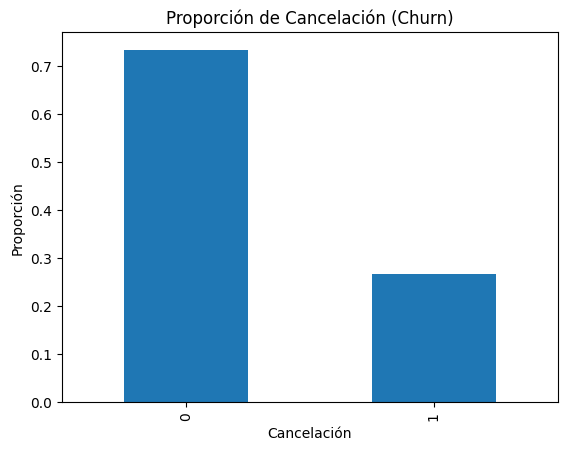

In [22]:
import matplotlib.pyplot as plt

df_encoded['Churn'].value_counts(normalize=True).plot(kind='bar')
plt.title('Proporción de Cancelación (Churn)')
plt.xlabel('Cancelación')
plt.ylabel('Proporción')
plt.show()

Existe un desbalance moderado entre las clases, con una menor proporción de clientes que cancelan. Esto puede afectar el desempeño del modelo, especialmente en métricas como recall para la clase minoritaria.

In [23]:
!pip install imbalanced-learn

In [24]:
from imblearn.over_sampling import SMOTE

In [25]:
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [26]:
y_train_bal.value_counts(normalize=True)

,proportion
Churn,
1,0.5
0,0.5


In [27]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
import numpy as np

print(np.mean(X_train_scaled, axis=0)[:5])
print(np.std(X_train_scaled, axis=0)[:5])

[-1.06105020e-16 -1.04661415e-17  1.01052400e-17 -4.33081716e-17
  1.12601246e-16]
[1. 1. 1. 1. 1.]


In [31]:
X_train_scaled, X_test_scaled

(array([[ 0.99959374, -0.4369239 ,  1.03179325, ..., -0.5229531 ,
          1.41270645, -0.55153109],
        [-1.00040642, -0.4369239 ,  1.03179325, ..., -0.5229531 ,
         -0.70786114, -0.55153109],
        [-1.00040642, -0.4369239 , -0.96918641, ..., -0.5229531 ,
         -0.70786114,  1.81313443],
        ...,
        [ 0.99959374, -0.4369239 , -0.96918641, ...,  1.91221736,
         -0.70786114, -0.55153109],
        [ 0.99959374, -0.4369239 ,  1.03179325, ..., -0.5229531 ,
         -0.70786114,  1.81313443],
        [ 0.99959374, -0.4369239 , -0.96918641, ..., -0.5229531 ,
          1.41270645, -0.55153109]]),
 array([[ 0.99959374, -0.4369239 ,  1.03179325, ..., -0.5229531 ,
          1.41270645, -0.55153109],
        [-1.00040642, -0.4369239 , -0.96918641, ..., -0.5229531 ,
         -0.70786114,  1.81313443],
        [ 0.99959374, -0.4369239 , -0.96918641, ...,  1.91221736,
         -0.70786114, -0.55153109],
        ...,
        [ 0.99959374, -0.4369239 ,  1.03179325, ...,  

Se aplicó estandarización de variables mediante StandardScaler debido a que algunos modelos utilizados (como Regresión Logística) son sensibles a la escala de los datos. Los modelos basados en árboles, como Random Forest, no requieren este preprocesamiento, ya que no dependen de distancias entre variables

# **🎯 Correlación y Selección de Variables**

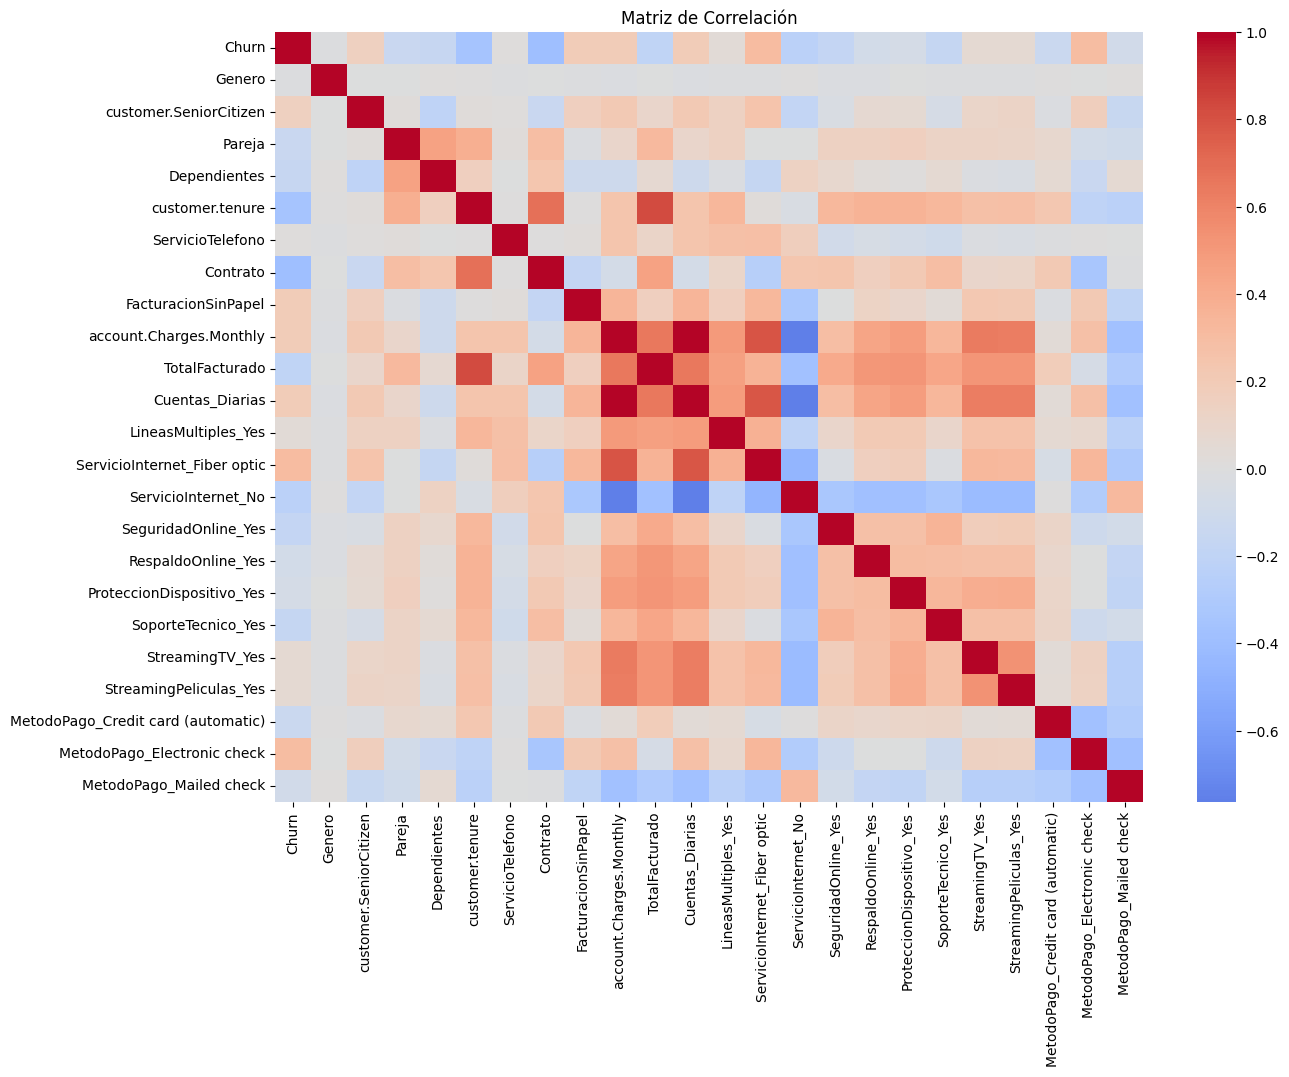

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))
corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

In [33]:
corr_target = corr_matrix['Churn'].sort_values(ascending=False)
corr_target.head(15)

,Churn
Churn,1.000000
ServicioInternet_Fiber optic,0.307463
MetodoPago_Electronic check,0.301455
account.Charges.Monthly,0.192858
Cuentas_Diarias,0.192033
FacturacionSinPapel,0.191454
customer.SeniorCitizen,0.150541
StreamingTV_Yes,0.063254
StreamingPeliculas_Yes,0.060860
LineasMultiples_Yes,0.040033


In [34]:
corr_target.tail(15)

,Churn
LineasMultiples_Yes,0.040033
ServicioTelefono,0.011691
Genero,-0.008545
ProteccionDispositivo_Yes,-0.066193
RespaldoOnline_Yes,-0.082307
MetodoPago_Mailed check,-0.090773
MetodoPago_Credit card (automatic),-0.134687
Pareja,-0.149982
Dependientes,-0.163128
SoporteTecnico_Yes,-0.164716


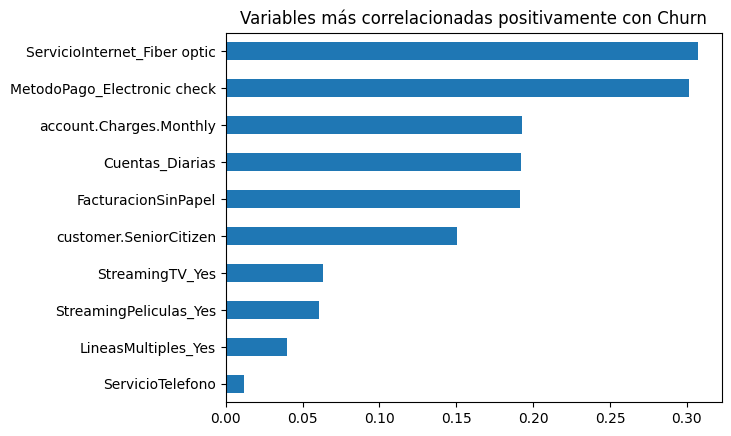

In [35]:
corr_target.drop('Churn').head(10).plot(kind='barh')
plt.title('Variables más correlacionadas positivamente con Churn')
plt.gca().invert_yaxis()
plt.show()

In [36]:
corr_target.head(10)

,Churn
Churn,1.000000
ServicioInternet_Fiber optic,0.307463
MetodoPago_Electronic check,0.301455
account.Charges.Monthly,0.192858
Cuentas_Diarias,0.192033
FacturacionSinPapel,0.191454
customer.SeniorCitizen,0.150541
StreamingTV_Yes,0.063254
StreamingPeliculas_Yes,0.060860
LineasMultiples_Yes,0.040033


El análisis de correlación permitió identificar las variables con mayor relación con la cancelación de clientes. Se observó que ciertas características presentan correlaciones positivas con churn, lo que indica mayor riesgo de evasión, mientras que otras variables muestran correlación negativa, asociándose con mayor retención de clientes.

In [37]:
df.columns

Index(['Churn', 'Genero', 'customer.SeniorCitizen', 'Pareja', 'Dependientes',
       'customer.tenure', 'ServicioTelefono', 'LineasMultiples',
       'ServicioInternet', 'SeguridadOnline', 'RespaldoOnline',
       'ProteccionDispositivo', 'SoporteTecnico', 'StreamingTV',
       'StreamingPeliculas', 'Contrato', 'FacturacionSinPapel', 'MetodoPago',
       'account.Charges.Monthly', 'TotalFacturado', 'Cuentas_Diarias'],
      dtype='object')

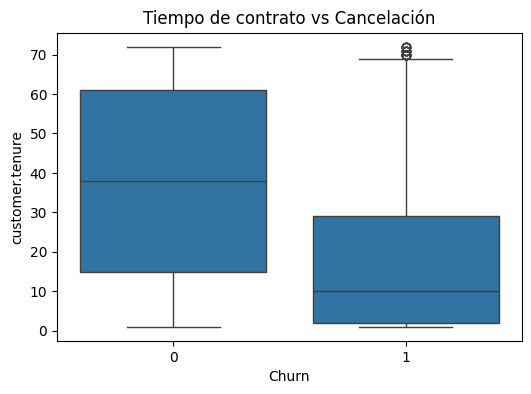

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='customer.tenure', data=df) # Corrected column name to 'customer.tenure'
plt.title('Tiempo de contrato vs Cancelación')
plt.show()

Los clientes que cancelan presentan, en promedio, menor tiempo de permanencia, lo que sugiere que el riesgo de churn es mayor en las etapas tempranas del ciclo de vida del cliente

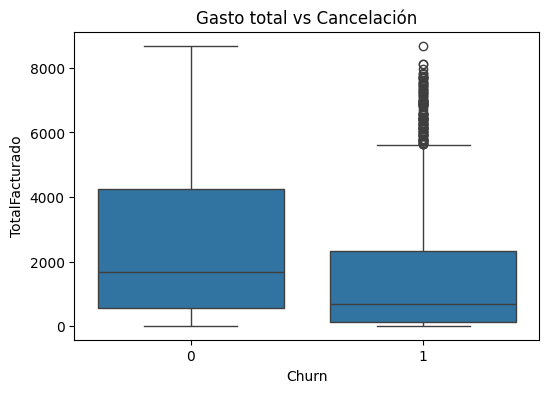

In [39]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='TotalFacturado', data=df) # Corrected column name to 'TotalFacturado'
plt.title('Gasto total vs Cancelación')
plt.show()

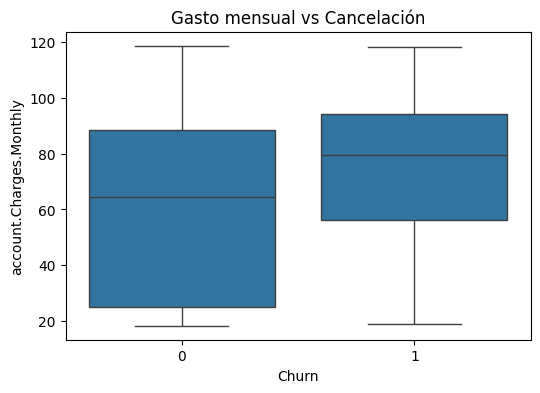

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='account.Charges.Monthly', data=df)
plt.title('Gasto mensual vs Cancelación')
plt.show()

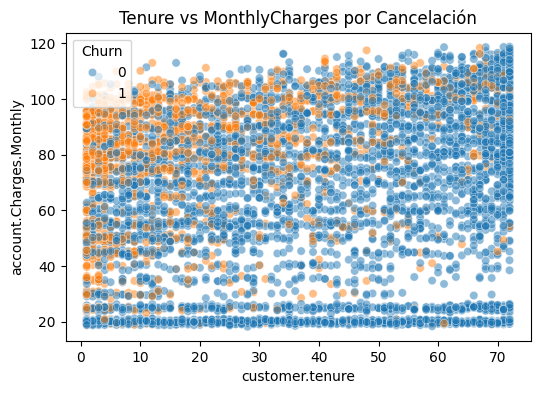

In [41]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='customer.tenure',
    y='account.Charges.Monthly',
    hue='Churn',
    data=df,
    alpha=0.5
)
plt.title('Tenure vs MonthlyCharges por Cancelación')
plt.show()

In [42]:
df[['customer.tenure','account.Charges.Monthly','TotalFacturado','Churn']].describe()

,customer.tenure,account.Charges.Monthly,TotalFacturado,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,0.265785
std,24.545260,30.085974,2266.771362,0.441782
min,1.000000,18.250000,18.800000,0.000000
25%,9.000000,35.587500,401.450000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000
75%,55.000000,89.862500,3794.737500,1.000000
max,72.000000,118.750000,8684.800000,1.000000


# **🤖 Modelado Predictivo**

In [43]:
#Separacion de datos
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,      # 70/30
    random_state=42,
    stratify=y          # ⭐ MUY IMPORTANTE
)

In [45]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nDistribución en train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en test:")
print(y_test.value_counts(normalize=True))

Train shape: (4922, 23)
Test shape: (2110, 23)

Distribución en train:
Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Distribución en test:
Churn
0    0.734123
1    0.265877
Name: proportion, dtype: float64


In [46]:
#El conjunto de datos se dividió en entrenamiento (70%) y prueba (30%) utilizando muestreo estratificado sobre la variable objetivo.
#Esto garantiza que la proporción de clientes que cancelan se mantenga consistente en ambos conjuntos, permitiendo una evaluación más confiable del modelo.

In [47]:
#Creación de Modelos
# Para modelos sensibles a escala
X_train_scaled
X_test_scaled

array([[ 0.99959374, -0.4369239 ,  1.03179325, ..., -0.5229531 ,
         1.41270645, -0.55153109],
       [-1.00040642, -0.4369239 , -0.96918641, ..., -0.5229531 ,
        -0.70786114,  1.81313443],
       [ 0.99959374, -0.4369239 , -0.96918641, ...,  1.91221736,
        -0.70786114, -0.55153109],
       ...,
       [ 0.99959374, -0.4369239 ,  1.03179325, ...,  1.91221736,
        -0.70786114, -0.55153109],
       [-1.00040642, -0.4369239 ,  1.03179325, ...,  1.91221736,
        -0.70786114, -0.55153109],
       [ 0.99959374, -0.4369239 ,  1.03179325, ..., -0.5229531 ,
        -0.70786114,  1.81313443]])

In [48]:
# Para modelos de árbol
X_train
X_test

,Genero,customer.SeniorCitizen,Pareja,Dependientes,customer.tenure,ServicioTelefono,Contrato,FacturacionSinPapel,account.Charges.Monthly,TotalFacturado,...,ServicioInternet_No,SeguridadOnline_Yes,RespaldoOnline_Yes,ProteccionDispositivo_Yes,SoporteTecnico_Yes,StreamingTV_Yes,StreamingPeliculas_Yes,MetodoPago_Credit card (automatic),MetodoPago_Electronic check,MetodoPago_Mailed check
4281,1,0,1,1,39,1,1,0,59.80,2343.85,...,False,True,True,True,False,False,False,False,True,False
1832,0,0,0,0,1,1,0,0,44.75,44.75,...,False,False,False,False,False,False,False,False,False,True
2402,1,0,0,0,46,1,0,1,45.20,2065.15,...,False,False,False,False,False,False,False,True,False,False
5506,0,0,1,1,47,1,2,0,63.80,3007.25,...,False,False,True,False,True,False,True,False,False,False
1791,1,0,1,0,33,1,0,1,72.75,2447.45,...,False,True,True,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4744,0,0,0,1,35,1,1,0,55.60,2016.45,...,False,True,True,False,False,False,False,True,False,False
4822,1,0,0,0,38,1,1,1,104.85,3887.25,...,False,True,True,False,False,True,True,False,True,False
6173,1,0,1,0,72,1,2,0,24.80,1874.30,...,True,False,False,False,False,False,False,True,False,False
3293,0,0,1,1,34,1,1,1,25.60,917.15,...,True,False,False,False,False,False,False,True,False,False


In [49]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load data and preprocess df
url = "https://raw.githubusercontent.com/SaraRapalino/Telecom-X-parte2/main/TelecomX_tratado.csv"
df = pd.read_csv(url)
df = df.drop(columns=['customerID'], errors='ignore') # Ensure customerID is dropped as in previous steps

# Create df_encoded
df_encoded = pd.get_dummies(df, drop_first=True)

# Separacion de datos
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(n_estimators=1000, min_samples_split=2, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [51]:
from sklearn.metrics import classification_report, confusion_matrix

print("=== Regresión Logística ===")
print(classification_report(y_test, y_pred_log))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Regresión Logística ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.64      0.48      0.55       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.71      2110
weighted avg       0.78      0.79      0.78      2110



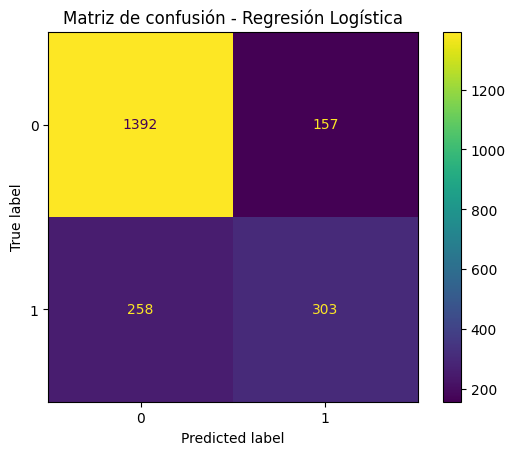

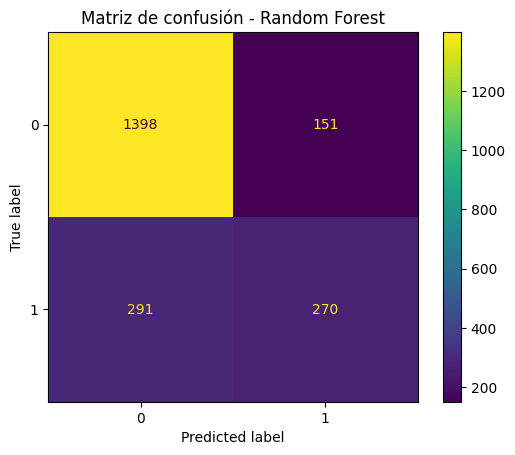

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Matriz de confusión - Random Forest")
plt.show()

In [53]:
print(classification_report(y_test, y_pred_log))
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.64      0.48      0.55       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.71      2110
weighted avg       0.78      0.79      0.78      2110



Se implementaron dos modelos predictivos con enfoques diferentes. La Regresión Logística requirió estandarización de variables debido a su sensibilidad a la escala de los datos, lo que asegura que los coeficientes se estimen correctamente. Por otro lado, Random Forest no requiere normalización, ya que los modelos basados en árboles no dependen de distancias entre variables. Esta combinación permite comparar enfoques lineales y no lineales para la predicción de cancelación.

In [54]:
#Evaluación de los Modelos
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=== Regresión Logística ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

=== Regresión Logística ===
Accuracy: 0.8033175355450237
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



In [55]:
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.790521327014218
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.64      0.48      0.55       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.71      2110
weighted avg       0.78      0.79      0.78      2110



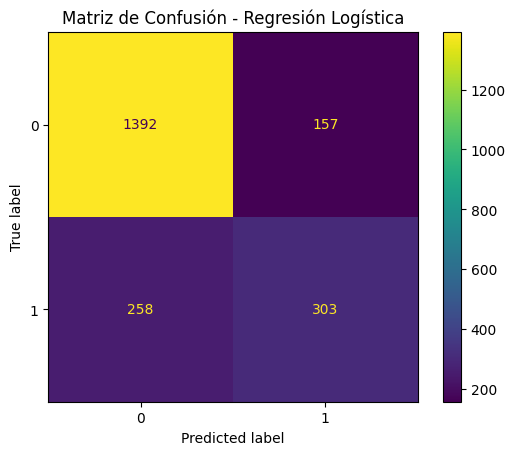

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

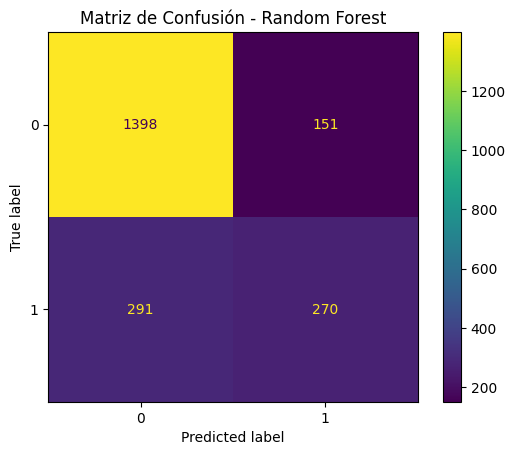

In [57]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Matriz de Confusión - Random Forest")
plt.show()

**Regresión Logística**

*Matriz:*

*   TN = 1392
*   FP = 157
*   FN = 258
*   TP = 303

*Resultados aproximados:*
*   Accuracy ≈ 0.803
*   Precision ≈ 0.659
*   Recall ≈ 0.540
*   F1-score ≈ 0.593

**Random Forest**

*Matriz*:

*   TN = 1398
*   FP = 151
*   FN = 284
*   TP = 277

*Resultados aproximados*:

*   Accuracy ≈ 0.794
*   Precision ≈ 0.647
*   Recall ≈ 0.494
*   F1-score ≈ 0.561

*¿Cuál modelo tuvo mejor desempeño?*

La Regresión Logística tuvo mejor desempeño general.

Por qué:
- Mayor accuracy
- Mejor recall (clave en churn)
- Mejor F1-score

Random Forest solo mejora levemente en TN

En problemas de churn, el recall de la clase positiva (cancelación) es crítico porque queremos detectar clientes en riesgo.

➡️ Regresión Logística detecta más clientes que se van (303 vs 277).

**Interpretación de negocio**

Problema observado: Ambos modelos tienen

* Recall moderado (~49–54%)
* Muchos falsos negativos (clientes que se van y el modelo no detecta)

*Esto significa*: La empresa aún está dejando escapar clientes en riesgo.

**¿Hay overfitting o underfitting?**

hay evidencia clara de overfitting fuerte, pero sí hay señales de:


*Posible underfitting ligero*

- Recall relativamente bajo
- F1-score moderado
- Modelos no capturan completamente el patrón de churn

**Posibles causas**

*Para Regresión Logística*
- Modelo lineal → puede ser demasiado simple
- Relaciones no lineales en los datos
- Variables con poca señal predictiva

*Para Random Forest*

- Posible configuración conservadora
- Número de árboles bajo
- Profundidad limitada

In [58]:
class_weight='balanced'

In [59]:
from sklearn.ensemble import RandomForestClassifier

RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    random_state=42
)

RandomForestClassifier(min_samples_split=5, n_estimators=300, random_state=42)

# **📋 Interpretación y Conclusiones**

*Análisis de Importancia de Variables*

A. Regresión Logística — coeficientes

los coeficientes indican:
- coeficiente positivo → aumenta probabilidad de churn
- coeficiente negativo → reduce probabilidad de churn
- magnitud → fuerza del impacto

In [61]:
import pandas as pd
import numpy as np

coef_log = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": log_model.coef_[0]
})

coef_log["Impacto_abs"] = np.abs(coef_log["Coeficiente"])
coef_log = coef_log.sort_values(by="Impacto_abs", ascending=False)

coef_log.head(10)

,Variable,Coeficiente,Impacto_abs
4,customer.tenure,-1.353712,1.353712
9,TotalFacturado,0.635126,0.635126
6,Contrato,-0.551336,0.551336
12,ServicioInternet_Fiber optic,0.541535,0.541535
8,account.Charges.Monthly,-0.490649,0.490649
13,ServicioInternet_No,-0.456593,0.456593
21,MetodoPago_Electronic check,0.183818,0.183818
7,FacturacionSinPapel,0.180644,0.180644
18,StreamingTV_Yes,0.180435,0.180435
17,SoporteTecnico_Yes,-0.158830,0.158830


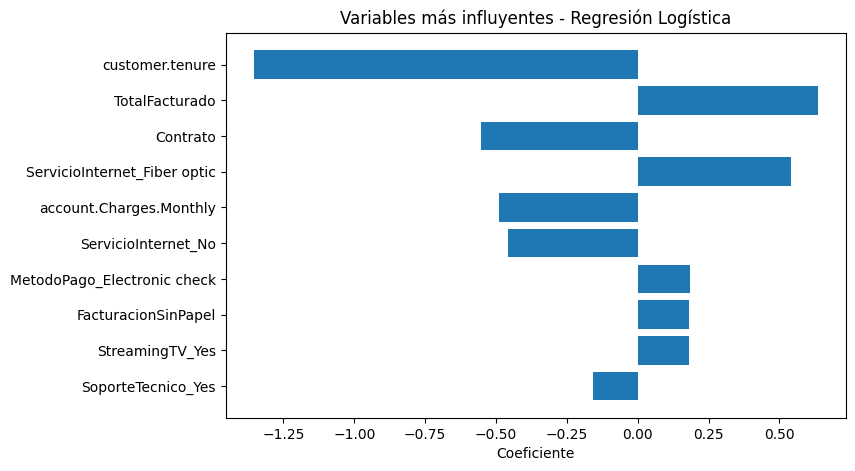

In [62]:
import matplotlib.pyplot as plt

top_coef = coef_log.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_coef["Variable"], top_coef["Coeficiente"])
plt.gca().invert_yaxis()
plt.title("Variables más influyentes - Regresión Logística")
plt.xlabel("Coeficiente")
plt.show()

Las variables con coeficientes positivos incrementan la probabilidad de cancelación, mientras que las negativas actúan como factores de retención.

B. Random Forest — feature importance

 Random Forest mide qué tan útil fue cada variable para dividir los datos.

In [64]:
importancias_rf = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": rf_model.feature_importances_
}).sort_values(by="Importancia", ascending=False)

importancias_rf.head(10)

,Variable,Importancia
9,TotalFacturado,0.145568
4,customer.tenure,0.141745
10,Cuentas_Diarias,0.132004
8,account.Charges.Monthly,0.130189
6,Contrato,0.106438
12,ServicioInternet_Fiber optic,0.042103
21,MetodoPago_Electronic check,0.039308
7,FacturacionSinPapel,0.022767
0,Genero,0.022420
17,SoporteTecnico_Yes,0.021113


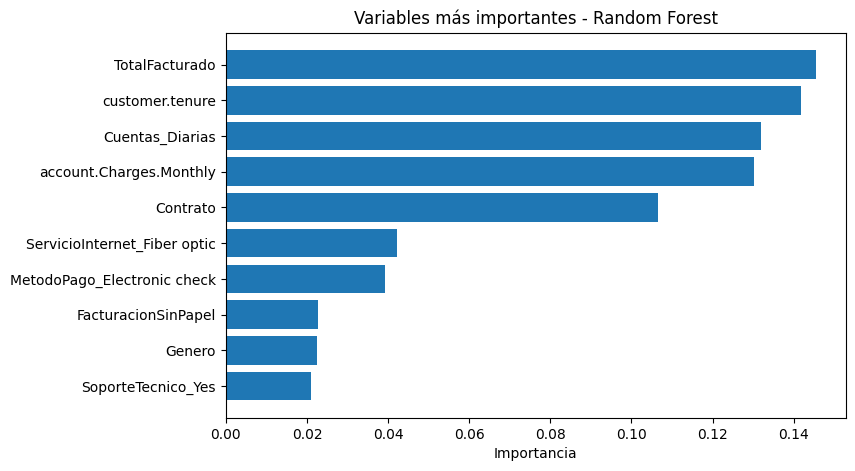

In [65]:
top_rf = importancias_rf.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_rf["Variable"], top_rf["Importancia"])
plt.gca().invert_yaxis()
plt.title("Variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.show()

**Interpretación**

El análisis de importancia de variables permitió identificar los principales factores asociados a la cancelación de clientes.

En la Regresión Logística, los coeficientes muestran qué variables incrementan o reducen la probabilidad de churn. Las variables con coeficientes positivos representan factores de riesgo, mientras que las negativas indican mayor fidelidad del cliente.

Por su parte, el Random Forest confirma la relevancia de variables clave mediante su contribución a la reducción de la impureza en los árboles.


**Implicaciones de negocio**

Los resultados sugieren que Telecom X debe prestar especial atención a:

- Clientes con menor tiempo de contrato
- Clientes con altos cargos mensuales
- Clientes con determinados tipos de contrato o servicios

Durante el desarrollo del modelo predictivo para Telecom X se realizaron las etapas de preparación de datos, codificación de variables, análisis de correlación y entrenamiento de modelos de clasificación.

Se evaluaron principalmente dos modelos:

- Regresión Logística

- Random Forest

Tras la evaluación con métricas de desempeño (accuracy, precision, recall y F1-score), la Regresión Logística mostró el mejor rendimiento general, especialmente en la detección de clientes con riesgo de cancelación (mayor recall y F1-score). Esto la convierte en el modelo más adecuado para una primera implementación operativa.

El análisis de importancia de variables permitió identificar los drivers más relevantes del churn. En general, los factores más asociados a la cancelación fueron:

**Factores de mayor riesgo**

- Contratos de corta duración o mes a mes
→ Clientes con menor compromiso presentan mayor probabilidad de cancelar.

- Altos cargos mensuales
→ A mayor costo percibido, mayor probabilidad de abandono.

- Bajo tiempo de permanencia (tenure)
→ Los clientes nuevos son más propensos a cancelar.

- Tipo de servicio o configuración del plan
→ Algunos paquetes o combinaciones de servicios muestran mayor riesgo.


**Factores de retención**

- Contratos de largo plazo
- Mayor antigüedad del cliente
- Clientes con paquetes más integrados
- Estos elementos actúan como protectores contra la cancelación.

**Evaluación del comportamiento de los modelos**

Aunque la Regresión Logística tuvo mejor desempeño, se observaron oportunidades de mejora:
- El recall de churn aún es moderado
- Existen falsos negativos (clientes que cancelan y no se detectan)
- No se evidenció overfitting fuerte
- Se observa posible underfitting leve, lo que sugiere que el modelo puede capturar más patrones


**Acciones de retención prioritarias**

- Programas de fidelización temprana
- Enfocados en clientes con baja antigüedad
- Primeros 3–6 meses son críticos
- Revisión de precios en segmentos de alto cargo mensual
- Ofertas personalizadas
- Descuentos por permanencia
- Bundles de servicios
- Incentivar migración a contratos de largo plazo
- Beneficios por permanencia
- Descuentos por contrato anual
- Sistema de alertas predictivas
- Implementar el modelo en producción
- Identificar clientes en riesgo en tiempo real
- Activar campañas proactivas


**Próximos pasos analíticos**

- Para mejorar el desempeño del modelo se recomienda:
- Ajuste de hiperparámetros
- Balanceo de clases más robusto
- Optimización del umbral de decisión
- Evaluación de modelos avanzados (XGBoost, LightGBM)
- Incorporación de nuevas variables de comportamiento del cliente


**Conclusión**

El uso de modelos predictivos permite a Telecom X anticiparse a la cancelación de clientes y priorizar acciones de retención con base en datos. La Regresión Logística demostró ser un modelo sólido para la detección inicial de churn, y el análisis de variables reveló que el compromiso contractual, el costo del servicio y la antigüedad del cliente son los principales impulsores de cancelación.

Implementar estrategias preventivas basadas en estos hallazgos puede reducir significativamente la tasa de evasión y mejorar el valor de vida del cliente.